## Project 1
Daniel Son, Hailey Chong, Alicia Yoo, Roman Gilbert, Derek Wang, Jun Hong

### Part 1: Wrangling and EDA (40/100 pts)

Read in base mortality file, demographics file, and inner merge

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
mdf = pd.read_csv('data/linked_mortality_file_1999_2000.csv') # Load mortality file
print(mdf.head())
gdf = pd.read_sas("data/DEMO.xpt", format="xport") # Load demographics file
print(gdf.head())
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

In [2]:
df[["ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX"]].head()

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX
0,2,NaN,NaN,31.0
1,1,1.0,177.0,926.0
2,2,NaN,NaN,126.0
3,2,NaN,NaN,23.0
4,1,0.0,244.0,597.0


`ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` descriptions:

`ELIGSTAT` (Eligibility Status for Mortality Linkage)

This variable indicates whether a NHANES participant could be successfully linked to the National Death Index (NDI) to determine mortality outcomes. Only participants with sufficient identifying information are eligible. If a participant is not eligible, their mortality status cannot be determined.

`MORTSTAT` (Mortality Status)

This variable shows the participant’s vital status at the end of the follow-up period based on NDI linkage. A value of 1 indicates the participant is assumed deceased, while 0 indicates the participant is assumed alive. This variable is only available for participants who are eligible for mortality linkage.

`PERMTH_INT` (Person-Months of Follow-Up from Interview)

This variable measures the total number of months a participant was followed starting from their NHANES interview date until either the date of death or the end of the follow-up period. It represents the amount of time each participant contributes to survival or mortality analysis.

`RIDAGEEX` (Age in Months at Examination)

This variable records the participant’s age in months at the time of their NHANES medical examination (MEC). Using age in months provides a more precise measure than age in years, which is especially important for younger participants and age-sensitive analyses.

Plotting the distribution of key mortality variables to check for skewness:


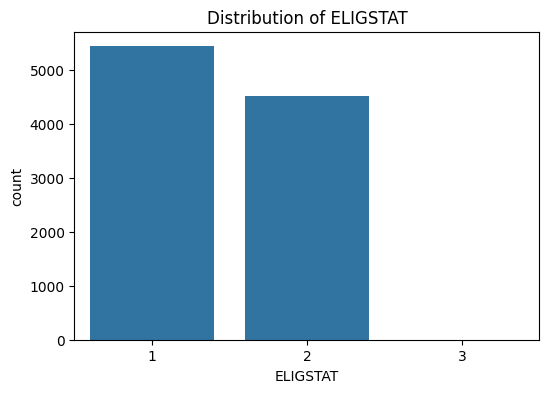

count    9965.000000
mean        1.453889
std         0.498499
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: ELIGSTAT, dtype: float64


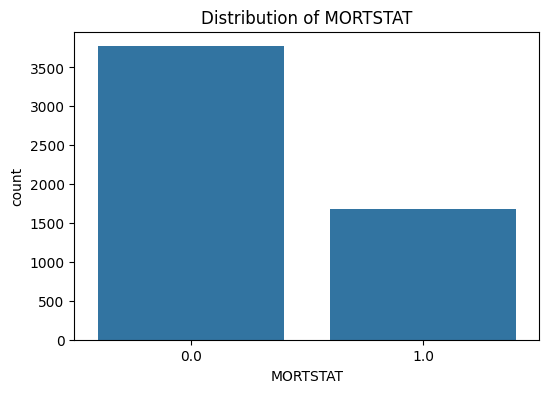

count    5445.000000
mean        0.307622
std         0.461551
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: MORTSTAT, dtype: float64


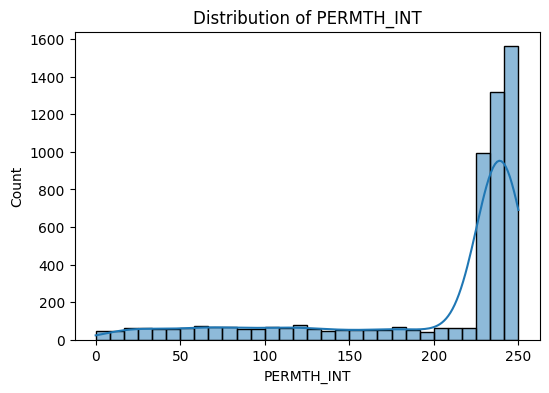

count    5445.000000
mean      202.314601
std        67.137767
min         0.000000
25%       194.000000
50%       235.000000
75%       242.000000
max       250.000000
Name: PERMTH_INT, dtype: float64


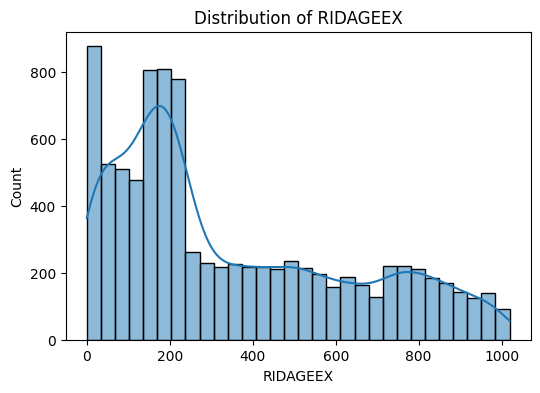

count    9.141000e+03
mean     3.453502e+02
std      2.835316e+02
min      5.397605e-79
25%      1.290000e+02
50%      2.280000e+02
75%      5.500000e+02
max      1.019000e+03
Name: RIDAGEEX, dtype: float64


In [3]:

plt.figure(figsize=(6, 4))
sns.countplot(x="ELIGSTAT", data=df)
plt.title("Distribution of ELIGSTAT")
plt.show()
print(df["ELIGSTAT"].describe())

plt.figure(figsize=(6, 4))
sns.countplot(x="MORTSTAT", data=df)
plt.title("Distribution of MORTSTAT")
plt.show()
print(df["MORTSTAT"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(df["PERMTH_INT"].dropna(), bins=30, kde=True)
plt.title("Distribution of PERMTH_INT")
plt.show()
print(df["PERMTH_INT"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(df["RIDAGEEX"].dropna(), bins=30, kde=True)
plt.title("Distribution of RIDAGEEX")
plt.show()
print(df["RIDAGEEX"].describe())

Merging the `BPX`, `BPQ`, and `SMQ` datasets on `SEQN`:

In [4]:
bpx_df = pd.read_sas("./data/BPX.xpt", format="xport")  # exam blood pressure
bpq_df = pd.read_sas("./data/BPQ.xpt", format="xport")  # questionnaire
smq_df = pd.read_sas("./data/SMQ.xpt", format="xport")  # smoking questionnaire

print(bpx_df.head())
print(bpq_df.head())
print(smq_df.head())

# Merging into main dataframe
df = df.merge(bpx_df, on="SEQN", how="left")
df = df.merge(bpq_df, on="SEQN", how="left")
df = df.merge(smq_df, on="SEQN", how="left")

print(df.shape)
print(df[["SEQN","ELIGSTAT","MORTSTAT","PERMTH_INT","RIDAGEEX"]].head())

   SEQN  PEASCST1  PEASCTM1      PEASCCT1  BPXCHR  BPQ150A  BPQ150B  BPQ150C  \
0   1.0       1.0     151.0  5.397605e-79   110.0      NaN      NaN      NaN   
1   2.0       1.0     764.0  5.397605e-79     NaN      2.0      2.0      2.0   
2   3.0       1.0     571.0  5.397605e-79     NaN      2.0      2.0      2.0   
3   4.0       1.0      47.0  5.397605e-79   108.0      NaN      NaN      NaN   
4   5.0       1.0     694.0  5.397605e-79     NaN      2.0      2.0      2.0   

   BPQ150D  BPAARM  ...  BPXDI2  BPAEN2  BPXSY3  BPXDI3  BPAEN3  BPXSY4  \
0      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
1      2.0     1.0  ...    56.0     2.0    98.0    56.0     2.0     NaN   
2      2.0     1.0  ...    64.0     2.0   112.0    62.0     2.0     NaN   
3      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4      2.0     1.0  ...    84.0     2.0   122.0    82.0     2.0     NaN   

   BPXDI4  BPAEN4  BPXSAR  BPXDAR  
0     NaN     NaN     NaN     Na

Rationale:
* `BPX` Blood Pressure Examination: Captures measured physiological responses, and blood pressure readings can be a good predictor of cardiovascular disease and stroke, which are all common causes of mortality. Hypertension is strongly associated with increased mortality risk.
* `BPQ` (Blood Pressure Questionnaire): Documents diagnosed hypertension and clinical history, which can reveal whether participants already knew they had high blood pressure. 
* `SMQ` (Smoking Questionnaire): Describes smoking history and current smoking behavior, providing a strong behavioral risk factor that’s tightly linked to mortality and reduced life expectancy. 

### EDA and Data Wrangling

Initial Data Exploration:

In [5]:
print(df.shape)
print(df.head())
print(df.columns)
print(df.dtypes)

(9965, 253)
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.0       1.0      49.0     597.0     597.0   

   RIDRETH1  RIDRETH2  ...  SMQ180  SMD190  SMQ200  SMD203  SMQ205  SMQ210  \
0       4.0       2.0  ...     NaN     NaN     NaN     NaN     NaN     NaN   
1       3.0       1.0  ...     2.0     NaN     NaN     NaN     NaN     2.0   
2       3.0       1.0  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3       4.0       2.0  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4       3.0       1.0  ...     2.0     NaN     NaN     NaN     NaN     1.0   

         SMD220  SMQ230  SMD233 

In [6]:
print(df.isna().sum().sum())
print(df.isna().mean().mean())

849482
0.3369429366418831


In [7]:
print(bpx_df.columns)
print(bpq_df.columns)
print(smq_df.columns)

Index(['SEQN', 'PEASCST1', 'PEASCTM1', 'PEASCCT1', 'BPXCHR', 'BPQ150A',
       'BPQ150B', 'BPQ150C', 'BPQ150D', 'BPAARM', 'BPACSZ', 'BPXPLS', 'BPXDB',
       'BPXPULS', 'BPXPTY', 'BPXML1', 'BPXSY1', 'BPXDI1', 'BPAEN1', 'BPXSY2',
       'BPXDI2', 'BPAEN2', 'BPXSY3', 'BPXDI3', 'BPAEN3', 'BPXSY4', 'BPXDI4',
       'BPAEN4', 'BPXSAR', 'BPXDAR'],
      dtype='object')
Index(['SEQN', 'BPQ010', 'BPQ020', 'BPQ030', 'BPQ040A', 'BPQ040B', 'BPQ040C',
       'BPQ040D', 'BPQ040E', 'BPQ040F', 'BPQ043A', 'BPQ043B', 'BPQ043C',
       'BPQ043D', 'BPQ050A', 'BPQ050B', 'BPQ050C', 'BPQ050D', 'BPQ050E',
       'BPQ060', 'BPQ070', 'BPQ080', 'BPQ090A', 'BPQ090B', 'BPQ090C',
       'BPQ090D', 'BPQ100A', 'BPQ100B', 'BPQ100C', 'BPQ100D', 'BPQ110A',
       'BPQ110B', 'BPQ110C', 'BPQ120', 'BPQ130', 'BPQ140'],
      dtype='object')
Index(['SEQN', 'SMQ020', 'SMD030', 'SMQ040', 'SMQ050Q', 'SMQ050U', 'SMD055',
       'SMD057', 'SMD070', 'SMD075', 'SMD080', 'SMD090', 'SMD100BR',
       'SMD100FL', 'SMD100MN', 'SMD100L

Just trying the first three columns of each dataset to see if the values could be used for KNN:

In [8]:
# selects the first three columns from bpx, bpq, and smq and shows descriptive stats
bpx_cols = [c for c in bpx_df.columns if c != "SEQN"][:3]
bpq_cols = [c for c in bpq_df.columns if c != "SEQN"][:3]
smq_cols = [c for c in smq_df.columns if c != "SEQN"][:3]

eda_cols = bpx_cols + bpq_cols + smq_cols

print(bpx_cols)
print(bpq_cols)
print(smq_cols)

# useful statistics
display(df[eda_cols].describe(include='all'))

# missing values 
print(df[eda_cols].isna().sum())

['PEASCST1', 'PEASCTM1', 'PEASCCT1']
['BPQ010', 'BPQ020', 'BPQ030']
['SMQ020', 'SMD030', 'SMQ040']


,PEASCST1,PEASCTM1,PEASCCT1,BPQ010,BPQ020,BPQ030,SMQ020,SMD030,SMQ040
count,9282.000000,9.282000e+03,9.282000e+03,6040.000000,5951.000000,1532.000000,4877.000000,2.292000e+03,2299.000000
mean,1.065719,5.787108e+02,1.686705e+00,1.596689,1.755503,1.189295,1.544187,2.083770e+01,2.207482
std,0.350767,3.255306e+02,1.078209e+01,1.071661,0.536916,0.513123,0.603811,5.839776e+01,0.938499
min,1.000000,5.397605e-79,5.397605e-79,1.000000,1.000000,1.000000,1.000000,5.397605e-79,1.000000
25%,1.000000,5.032500e+02,5.397605e-79,1.000000,1.000000,1.000000,1.000000,1.500000e+01,1.000000
50%,1.000000,6.510000e+02,5.397605e-79,1.000000,2.000000,1.000000,2.000000,1.700000e+01,3.000000
75%,1.000000,7.670000e+02,5.397605e-79,2.000000,2.000000,1.000000,2.000000,2.000000e+01,3.000000
max,3.000000,4.051000e+03,9.900000e+01,9.000000,9.000000,9.000000,9.000000,9.990000e+02,3.000000


PEASCST1     683
PEASCTM1     683
PEASCCT1     683
BPQ010      3925
BPQ020      4014
BPQ030      8433
SMQ020      5088
SMD030      7673
SMQ040      7666
dtype: int64


We selected the first 3 variables from each of the chosen datasets (BPX, BPQ, SMQ) for the sake of consistency. Some are categorical while others are numerical.

Here is a brief description of what these variables represent based on NHANES 1999–2000 documentation:

Blood Pressure Examination (BPX):
* PEASCST1: Blood Pressure Status (1=Complete, 2=Partial, 3=Not done). Indicates whether the blood pressure exam measurement was completed.
* PEASCTM1: Blood Pressure Time (seconds). A numeric time value associated with the blood pressure measurement component.
* PEASCCT1: Blood Pressure Comment (0=None, 1=Safety exclusion, 2=SP refusal, 3=No time, 4=Physical limitation, 5=Communication problem, 6=Equipment failure, 7=SP ill/emergency, 56=Came late/left early, 99=Other).

Blood Pressure Questionnaire (BPQ):
* BPQ010: About how long has it been since you last had your blood pressure taken by a doctor or other health professional? (coded categories such as <6 months, 6 months–1 year, >1–2 years, >2 years, Never; plus refused/don’t know).
* BPQ020: Have you ever been told by a doctor or other health professional that you had hypertension, also called high blood pressure? (1=Yes, 2=No; plus refused/don’t know).
* BPQ030: Were you told on 2 or more different visits that you had hypertension, also called high blood pressure? (1=Yes, 2=No; plus refused/don’t know).

Smoking Questionnaire (SMQ):
* SMQ020: Have you smoked at least 100 cigarettes in your entire life? (1=Yes, 2=No; plus refused/don’t know).
* SMD030: How old were you when you first started to smoke cigarettes fairly regularly? (age in years; 0=Never smoked regularly; plus refused/don’t know).
* SMQ040: Do you now smoke cigarettes? (1=Every day, 2=Some days, 3=Not at all; plus refused/don’t know).

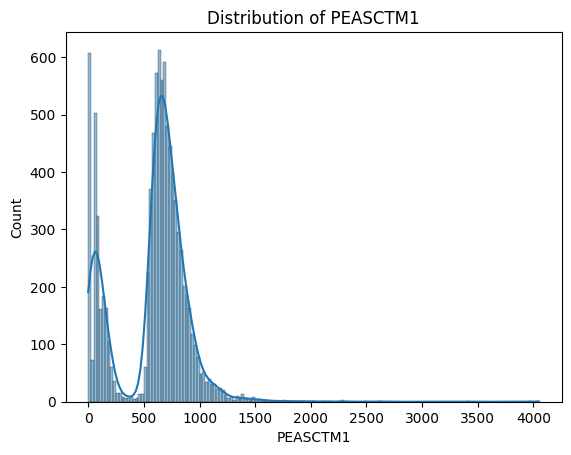

count    9.282000e+03
mean     5.787108e+02
std      3.255306e+02
min      5.397605e-79
25%      5.032500e+02
50%      6.510000e+02
75%      7.670000e+02
max      4.051000e+03
Name: PEASCTM1, dtype: float64


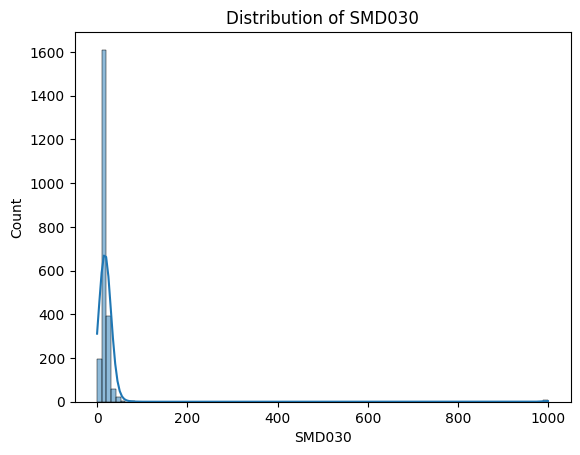

count    2.292000e+03
mean     2.083770e+01
std      5.839776e+01
min      5.397605e-79
25%      1.500000e+01
50%      1.700000e+01
75%      2.000000e+01
max      9.990000e+02
Name: SMD030, dtype: float64


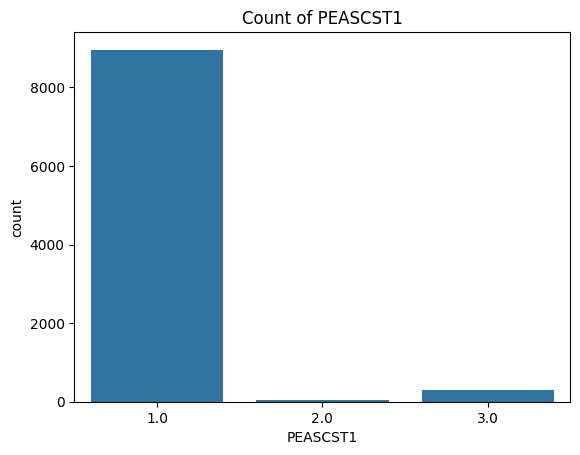

PEASCST1
1.0    8958
3.0     286
2.0      38
Name: count, dtype: int64


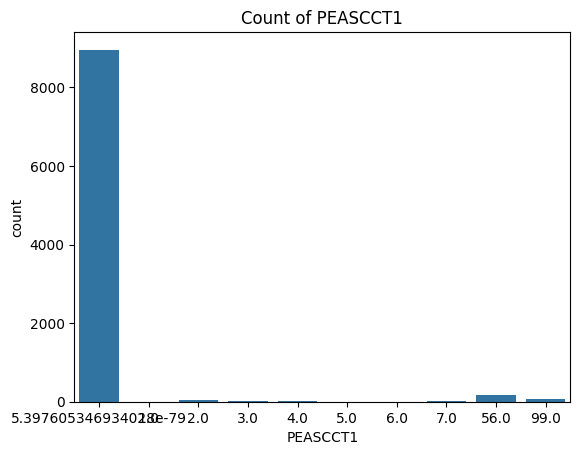

PEASCCT1
5.397605e-79    8960
5.600000e+01     174
9.900000e+01      57
2.000000e+00      52
3.000000e+00      15
7.000000e+00       9
4.000000e+00       7
5.000000e+00       4
1.000000e+00       3
6.000000e+00       1
Name: count, dtype: int64


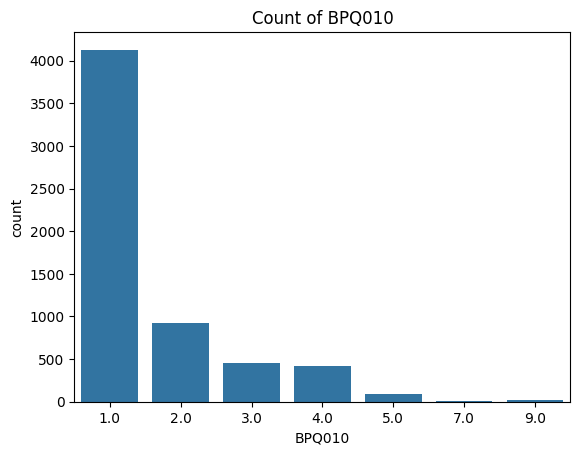

BPQ010
1.0    4129
2.0     922
3.0     460
4.0     424
5.0      86
9.0      16
7.0       3
Name: count, dtype: int64


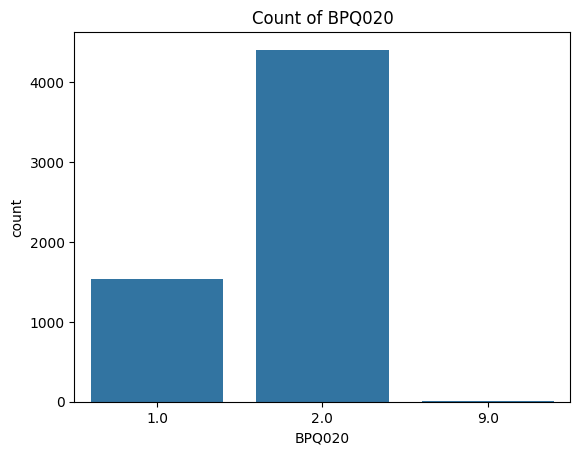

BPQ020
2.0    4408
1.0    1532
9.0      11
Name: count, dtype: int64


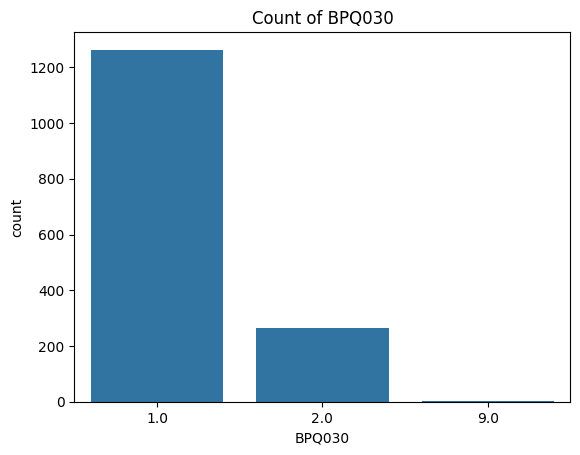

BPQ030
1.0    1263
2.0     266
9.0       3
Name: count, dtype: int64


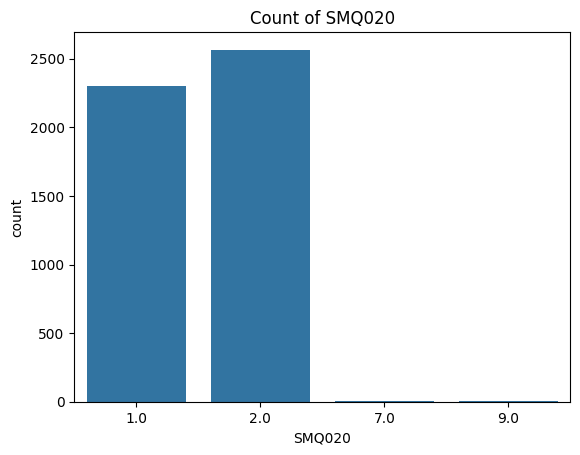

SMQ020
2.0    2566
1.0    2299
9.0       8
7.0       4
Name: count, dtype: int64


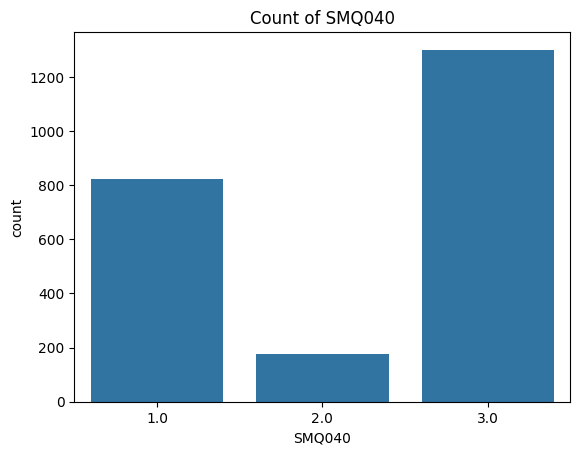

SMQ040
3.0    1300
1.0     823
2.0     176
Name: count, dtype: int64


In [9]:
# plots histograms for numeric variables and countplots for categorical variables
numeric_cols = ['PEASCTM1', 'SMD030']
for col in numeric_cols:
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()
        print(df[col].describe())

categorical_cols = [c for c in eda_cols if c not in numeric_cols]
for col in categorical_cols:
    if col in df.columns:
        sns.countplot(x=col, data=df)
        plt.title(f"Count of {col}")
        plt.show()
        print(df[col].value_counts())

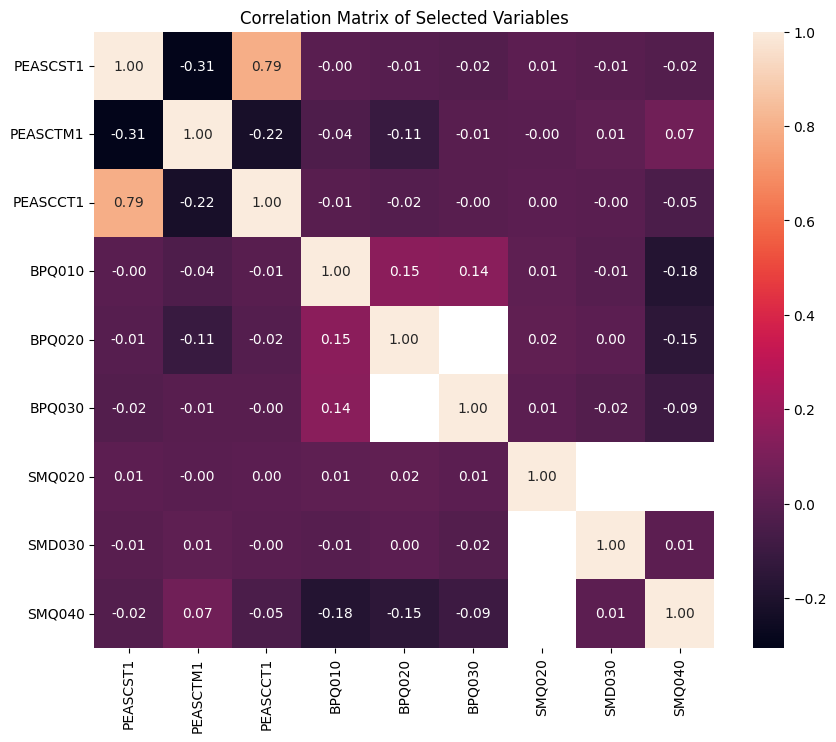

In [10]:
# correlation heatmap of the selected variables
plt.figure(figsize=(10, 8))
correlation_matrix = df[eda_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Selected Variables")
plt.show()

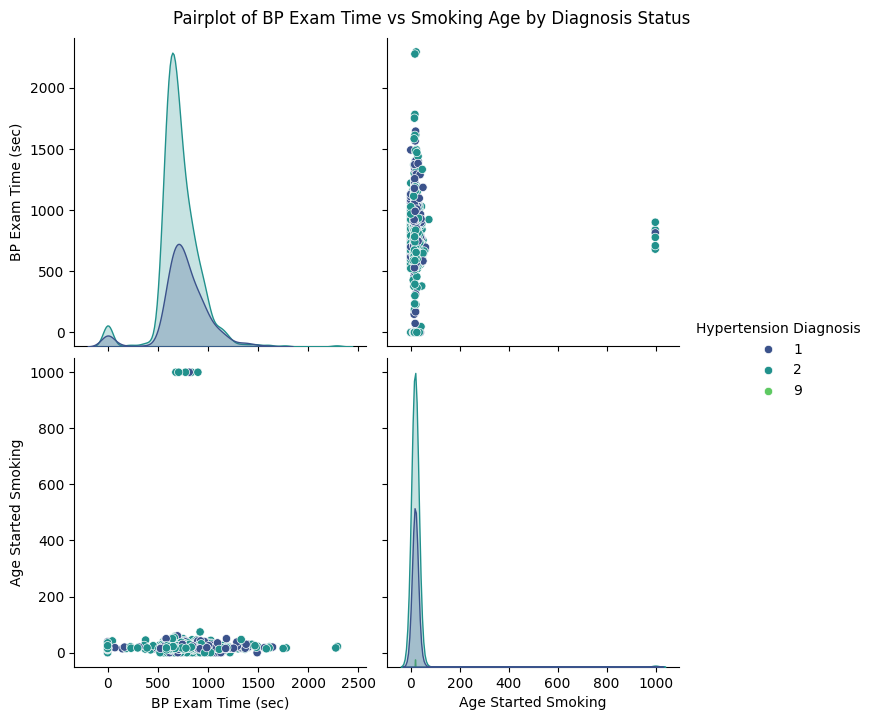

In [11]:
# pair plot of bp exam time and age started smoking by hypertension diagnosis
pairplot_data = df[['PEASCTM1', 'SMD030', 'BPQ020']].copy()
pairplot_data.columns = ['BP Exam Time (sec)', 'Age Started Smoking', 'Hypertension Diagnosis']
pairplot_data = pairplot_data.dropna()
pairplot_data['Hypertension Diagnosis'] = pairplot_data['Hypertension Diagnosis'].astype(int).astype(str)
sns.pairplot(pairplot_data, hue='Hypertension Diagnosis', palette='viridis', height=3.5)
plt.suptitle("Pairplot of BP Exam Time vs Smoking Age by Diagnosis Status", y=1.02)
plt.show()

The columns weren't too great for KNN because:
1) There were way too many missing values 
2) These columns do not seem likenecessarily great indicators of mortality

**Redone process below:**

Just initial merges to start with a clean slate:

In [12]:
mdf = pd.read_csv('data/linked_mortality_file_1999_2000.csv') # Load mortality file
gdf = pd.read_sas("data/DEMO.xpt", format="xport") # Load demographics file
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

In [13]:
bpx_df = pd.read_sas("./data/BPX.xpt", format="xport")  # exam blood pressure
bpq_df = pd.read_sas("./data/BPQ.xpt", format="xport")  # questionnaire
smq_df = pd.read_sas("./data/SMQ.xpt", format="xport")  # smoking questionnaire
# Merging into main dataframe
df = df.merge(bpx_df, on="SEQN", how="left")
df = df.merge(bpq_df, on="SEQN", how="left")
df = df.merge(smq_df, on="SEQN", how="left")

We selected 5 variables from each of the chosen datasets (BPX, BPQ, SMQ) to capture a mix of clinical measurements, diagnosis/treatment history, and smoking behavior. Some are categorical while others are numerical.

Here is a brief description of what these variables represent based on NHANES 1999–2000 documentation:

Blood Pressure Examination (`BPX`):
* BPXSAR: Systolic blood pressure average reported to the examinee (mm Hg).
* BPXDAR: Diastolic blood pressure average reported to the examinee (mm Hg). Calculated using the same reporting protocol as BPXSAR (with special handling when diastolic readings are 0).
* BPXPLS: 60-second pulse rate (30-second pulse × 2). Numeric pulse value (beats per minute).
* BPXPULS: Pulse regular or irregular? (1=Regular, 2=Irregular).
* BPXDB: Number of dropped beats in 30 seconds (numeric count).

Blood Pressure Questionnaire (`BPQ`):
* BPQ020: Ever told you had hypertension/high blood pressure? (1=Yes, 2=No; 7=Refused, 9=Don’t know).
* BPQ030: Told on 2 or more different visits that you had hypertension/high blood pressure? (1=Yes, 2=No; 7=Refused, 9=Don’t know).
* BPQ050A: Now taking prescribed medicine (asked in the context of hypertension-related advice/actions). (1=Yes, 2=No; 7=Refused, 9=Don’t know).
* BPQ040C: Told to cut down on salt or sodium in diet because of hypertension/high blood pressure. (1=Yes, 2=No; 7=Refused, 9=Don’t know).
* BPQ080: Ever told by a doctor/health professional that blood cholesterol level was high? (1=Yes, 2=No; 7=Refused, 9=Don’t know). Note: asked for ages 20+.

Smoking Questionnaire (`SMQ`):
* SMQ040: Do you now smoke cigarettes? (1=Every day, 2=Some days, 3=Not at all; 7=Refused, 9=Don’t know).
* SMD070: On average, how many cigarettes do you now smoke per day? (numeric; 777=Refused, 999=Don’t know).
* SMD080: On how many of the past 30 days did you smoke a cigarette? (0–30; 77=Refused, 99=Don’t know).
* SMD090: During the past 30 days, on the days you smoked, about how many cigarettes did you smoke per day? (numeric; 777=Refused, 999=Don’t know).
* SMD100MN: Menthol indicator for cigarette product (0=Non-menthol, 1=Menthol).

Sources: 

https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BPX.htm

https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/SMQ.htm

https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BPQ.htm


In [14]:
bpx_cols = ["BPXSAR", "BPXDAR", "BPXPLS", "BPXPULS", "BPXDB"]
bpq_cols = ["BPQ020", "BPQ030", "BPQ050A", "BPQ040C", "BPQ080"]
smq_cols = ["SMQ040", "SMD070", "SMD080", "SMD090", "SMD100MN"]
x_cols = bpx_cols + bpq_cols + smq_cols

missing = [c for c in x_cols if c not in df.columns]
print("Missing columns from df:", missing)

x_cols = [c for c in x_cols if c in df.columns]
print("Final X_COLS:", x_cols)

Missing columns from df: []
Final X_COLS: ['BPXSAR', 'BPXDAR', 'BPXPLS', 'BPXPULS', 'BPXDB', 'BPQ020', 'BPQ030', 'BPQ050A', 'BPQ040C', 'BPQ080', 'SMQ040', 'SMD070', 'SMD080', 'SMD090', 'SMD100MN']


In [15]:
print(bpx_cols)
print(bpq_cols)
print(smq_cols)

# useful statistics
display(df[x_cols].describe(include='all'))

# missing values 
print(df[x_cols].isna().sum())

['BPXSAR', 'BPXDAR', 'BPXPLS', 'BPXPULS', 'BPXDB']
['BPQ020', 'BPQ030', 'BPQ050A', 'BPQ040C', 'BPQ080']
['SMQ040', 'SMD070', 'SMD080', 'SMD090', 'SMD100MN']


,BPXSAR,BPXDAR,BPXPLS,BPXPULS,BPXDB,BPQ020,BPQ030,BPQ050A,BPQ040C,BPQ080,SMQ040,SMD070,SMD080,SMD090,SMD100MN
count,7215.000000,7.215000e+03,7253.000000,9003.000000,57.000000,5951.000000,1532.000000,1225.000000,1532.000000,3191.000000,2299.000000,823.000000,9.990000e+02,999.000000,9.200000e+02
mean,119.438808,6.734484e+01,73.980698,1.029657,2.701754,1.755503,1.189295,1.127347,1.357050,1.691633,2.207482,18.735115,2.603904e+01,15.705706,2.750000e-01
std,20.166079,1.439214e+01,12.752931,0.169648,1.636251,0.536916,0.513123,0.333497,0.599201,0.818395,0.938499,49.749033,8.580252e+00,33.301313,4.467571e-01
min,73.000000,5.397605e-79,36.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.397605e-79,1.000000,5.397605e-79
25%,106.000000,6.000000e+01,64.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.500000,3.000000e+01,5.000000,5.397605e-79
50%,115.000000,6.800000e+01,72.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000,15.000000,3.000000e+01,10.000000,5.397605e-79
75%,128.000000,7.600000e+01,82.000000,1.000000,4.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000,20.000000,3.000000e+01,20.000000,1.000000e+00
max,233.000000,1.320000e+02,142.000000,2.000000,6.000000,9.000000,9.000000,2.000000,9.000000,9.000000,3.000000,999.000000,7.700000e+01,999.000000,1.000000e+00


BPXSAR      2750
BPXDAR      2750
BPXPLS      2712
BPXPULS      962
BPXDB       9908
BPQ020      4014
BPQ030      8433
BPQ050A     8740
BPQ040C     8433
BPQ080      6774
SMQ040      7666
SMD070      9142
SMD080      8966
SMD090      8966
SMD100MN    9045
dtype: int64


There are still a lot of missing columns, so I implemented an algorithm to find the top ten variables with the least missing values per dataset below:

In [16]:
# Analyze missingness across ALL columns in the original dataframes
datasets = {"BPX (Exam)": bpx_df, "BPQ (Questionnaire)": bpq_df, "SMQ (Smoking)": smq_df}
best_vars = []

for name, dataset in datasets.items():
    print(f"--- Top 10 Variables with Least Missingness in {name} ---")
    # Calculate missing percentage
    missing = dataset.isnull().mean() * 100
    # Sort by least missing
    sorted_missing = missing.sort_values()
    print(sorted_missing.head(10))
    print("\n")
    
    # Select columns with < 50% missing values (excluding SEQN which is the ID)
    good_cols = sorted_missing[sorted_missing < 50].index.tolist()
    if "SEQN" in good_cols:
        good_cols.remove("SEQN")
        
    best_vars.extend(good_cols)

print(f"Selected {len(best_vars)} variables with < 50% missing data across all 3 datasets.")
print(best_vars)

# Update x_cols to use these "best" variables
x_cols = best_vars

--- Top 10 Variables with Least Missingness in BPX (Exam) ---
SEQN         0.000000
PEASCST1     0.000000
PEASCTM1     0.000000
PEASCCT1     0.000000
BPXPULS      3.005818
BPQ150A     21.784098
BPQ150B     21.784098
BPQ150C     21.784098
BPQ150D     21.784098
BPAARM      21.784098
dtype: float64


--- Top 10 Variables with Least Missingness in BPQ (Questionnaire) ---
SEQN        0.000000
BPQ010      0.066181
BPQ020      1.538716
BPQ060     19.308405
BPQ110A    38.600265
BPQ110C    38.600265
BPQ110B    38.600265
BPQ080     47.203839
BPQ070     47.203839
BPQ040D    74.652548
dtype: float64


--- Top 10 Variables with Least Missingness in SMQ (Smoking) ---
SEQN         0.000000
SMD100BR     0.000000
SMQ210       0.061475
SMQ180       0.061475
SMQ150       0.061475
SMQ120       0.061475
SMQ020       0.061475
SMQ040      52.889344
SMD030      53.032787
SMQ050Q     73.360656
dtype: float64


Selected 38 variables with < 50% missing data across all 3 datasets.
['PEASCST1', 'PEASCTM1', 'PEASCC

In [17]:
# BPX Variables (Exam)
bpx_best = [
    'PEASCST1', 'PEASCTM1', 'PEASCCT1', 'BPXPULS', 'BPAARM', 
    'BPXPTY', 'BPXPLS', 'BPACSZ', 'BPXML1', 'BPAEN1', 'BPAEN2', 'BPAEN3', 
    'BPXSAR', 'BPXDAR', # Averages
    'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3' # Individual readings
]

# BPQ Variables (Questionnaire)
bpq_best = [
    'BPQ010', 'BPQ020', 'BPQ060', 'BPQ070', 'BPQ080', 
    'BPQ110A', 'BPQ110B', 'BPQ110C', 
]

# SMQ Variables (Smoking)
smq_best = [
    'SMD100BR', 'SMQ210', 'SMQ180', 'SMQ150', 'SMQ120', 'SMQ020'
]

best_vars = bpx_best + bpq_best + smq_best

x_cols = [c for c in best_vars if c in df.columns]

print(f"Final Selection: {len(x_cols)} variables.")
print(x_cols)

# Separate into Numeric and Categorical for clearer EDA
# Heuristic: < 10 unique values = Categorical, >= 10 = Numeric
numeric_vars = [c for c in x_cols if df[c].nunique() >= 10]
categorical_vars = [c for c in x_cols if df[c].nunique() < 10]

print(f"\nNumeric Variables ({len(numeric_vars)}): {numeric_vars}")
print(f"Categorical Variables ({len(categorical_vars)}): {categorical_vars}")

Final Selection: 34 variables.
['PEASCST1', 'PEASCTM1', 'PEASCCT1', 'BPXPULS', 'BPAARM', 'BPXPTY', 'BPXPLS', 'BPACSZ', 'BPXML1', 'BPAEN1', 'BPAEN2', 'BPAEN3', 'BPXSAR', 'BPXDAR', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPQ010', 'BPQ020', 'BPQ060', 'BPQ070', 'BPQ080', 'BPQ110A', 'BPQ110B', 'BPQ110C', 'SMD100BR', 'SMQ210', 'SMQ180', 'SMQ150', 'SMQ120', 'SMQ020']

Numeric Variables (13): ['PEASCTM1', 'PEASCCT1', 'BPXPLS', 'BPXML1', 'BPXSAR', 'BPXDAR', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'SMD100BR']
Categorical Variables (21): ['PEASCST1', 'BPXPULS', 'BPAARM', 'BPXPTY', 'BPACSZ', 'BPAEN1', 'BPAEN2', 'BPAEN3', 'BPQ010', 'BPQ020', 'BPQ060', 'BPQ070', 'BPQ080', 'BPQ110A', 'BPQ110B', 'BPQ110C', 'SMQ210', 'SMQ180', 'SMQ150', 'SMQ120', 'SMQ020']


Checking to see if these are better at all:

In [18]:
print(df[x_cols].isna().sum())


PEASCST1     683
PEASCTM1     683
PEASCCT1     683
BPXPULS      962
BPAARM      2705
BPXPTY      2709
BPXPLS      2712
BPACSZ      2721
BPXML1      2736
BPAEN1      2737
BPAEN2      2737
BPAEN3      2737
BPXSAR      2750
BPXDAR      2750
BPXSY1      3508
BPXDI1      3508
BPXSY2      3597
BPXDI2      3597
BPXSY3      3709
BPXDI3      3710
BPQ010      3925
BPQ020      4014
BPQ060      5088
BPQ070      6774
BPQ080      6774
BPQ110A     6254
BPQ110B     6254
BPQ110C     6254
SMD100BR    5085
SMQ210      5088
SMQ180      5088
SMQ150      5088
SMQ120      5088
SMQ020      5088
dtype: int64


Visualizing our variables:

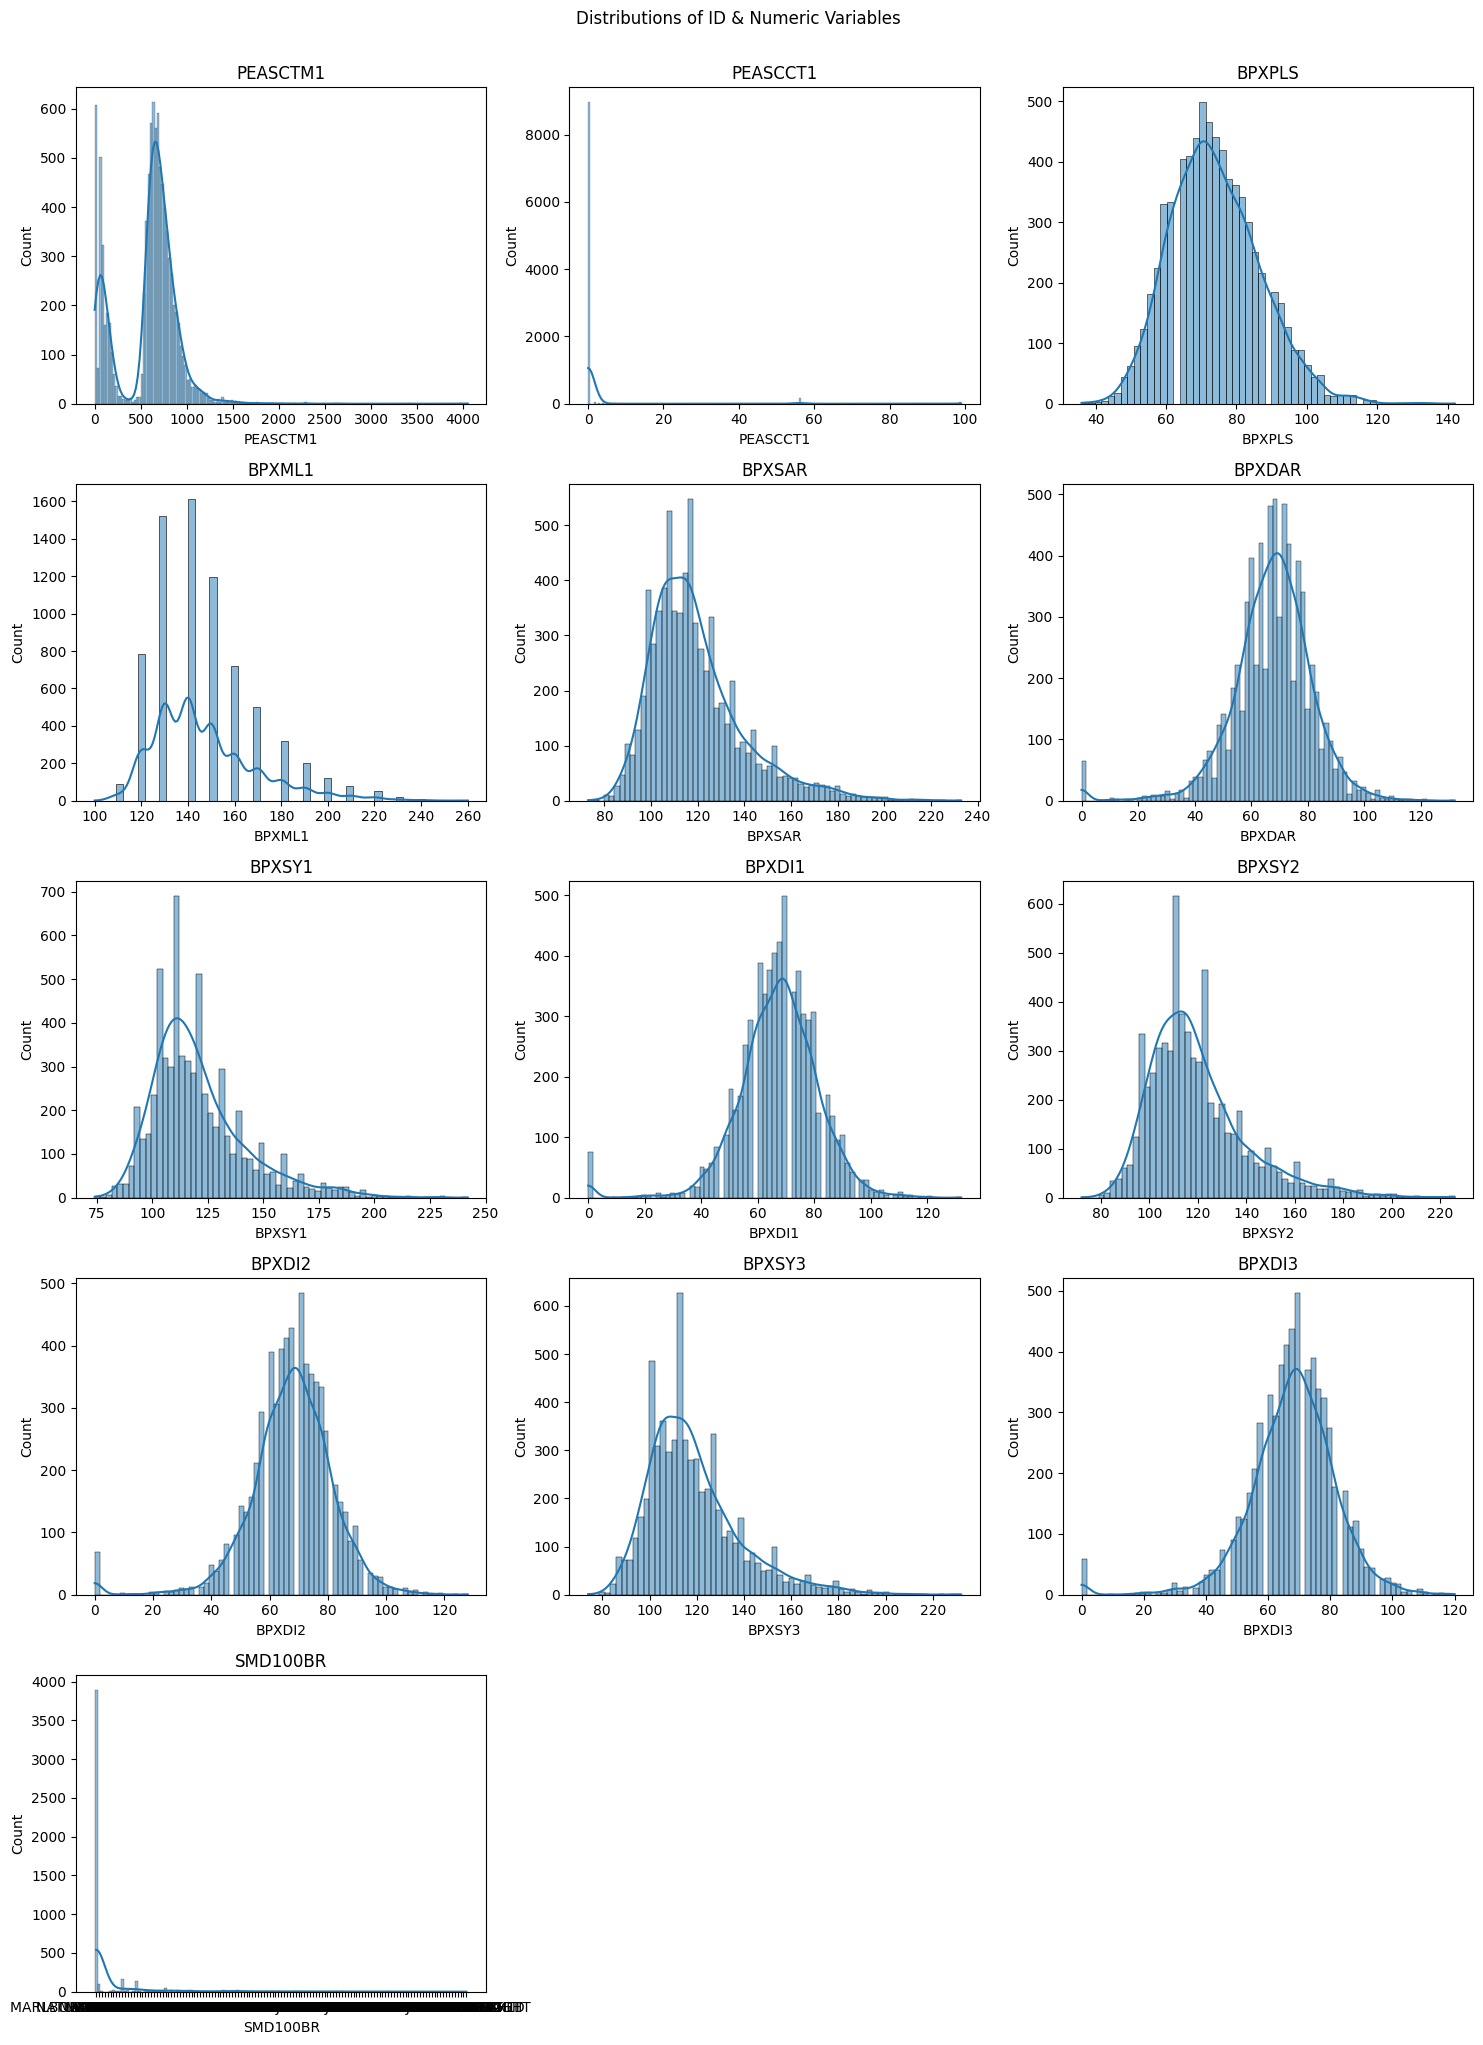

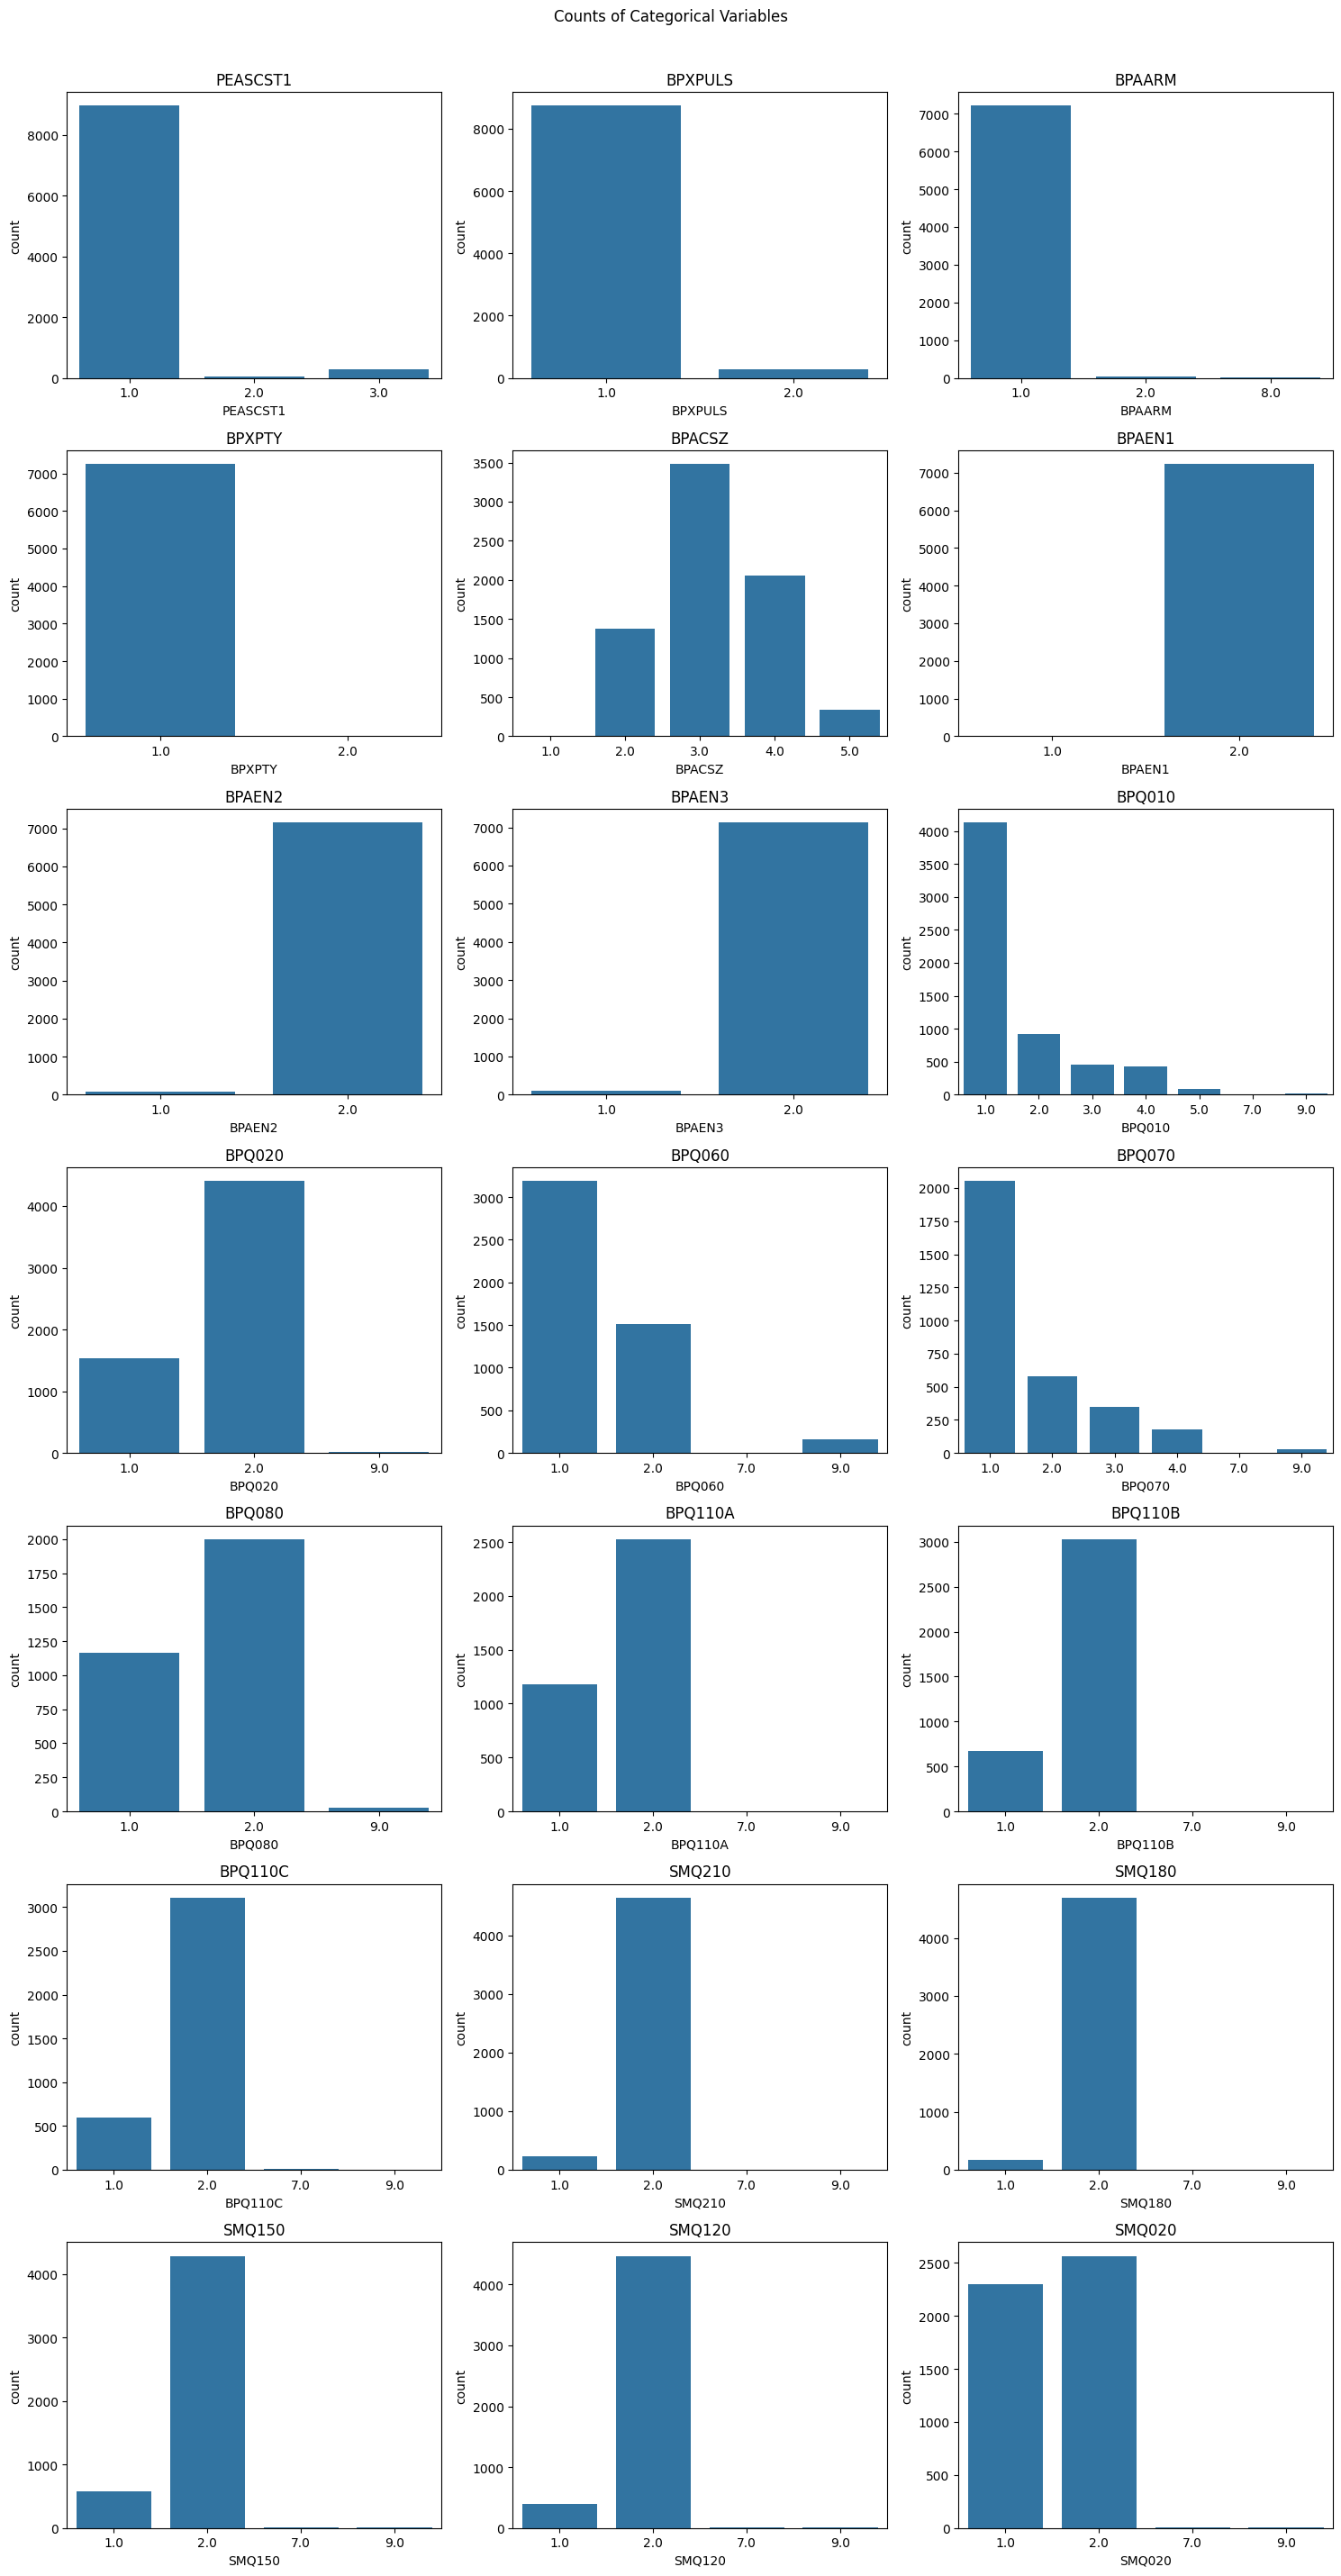

In [19]:
# 3. Visualize Distributions

# Histograms for Numeric Variables
if len(numeric_vars) > 0:
    n_cols = 3
    n_rows = (len(numeric_vars) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_vars):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)
        
    for i in range(len(numeric_vars), len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.suptitle("Distributions of ID & Numeric Variables", y=1.02)
    plt.show()

# Countplots for Categorical Variables
if len(categorical_vars) > 0:
    n_cols = 3
    n_rows = (len(categorical_vars) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(categorical_vars):
        sns.countplot(x=col, data=df, ax=axes[i])
        axes[i].set_title(col)
        
    for i in range(len(categorical_vars), len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.suptitle("Counts of Categorical Variables", y=1.02)
    plt.show()

In [20]:
target_col = "MORTSTAT"

# complete-case count for current feature set
complete_cases = df[x_cols + [target_col]].dropna()

total_n = len(df)
complete_n = len(complete_cases)
complete_pct = 100 * complete_n / total_n

# missingness per feature + “strict” subset
missing_percent = df[x_cols].isna().mean()
strict_cols = missing_percent[missing_percent < 0.20].index.tolist()

complete_cases_strict = df[strict_cols + [target_col]].dropna()
strict_n = len(complete_cases_strict)
strict_pct = 100 * strict_n / total_n

print(f"Total rows: {total_n}")
print(f"Complete cases (x_cols): {complete_n} ({complete_pct:.2f}%)")
print(f"Strict cols (<20% missing): {len(strict_cols)}")
print(f"Complete cases (strict): {strict_n} ({strict_pct:.2f}%)")

# optional: update x_cols if strict saves a lot more rows
if strict_n > complete_n * 1.5:
    x_cols = strict_cols

numeric_vars = [c for c in x_cols if df[c].nunique(dropna=True) >= 10]
categorical_vars = [c for c in x_cols if df[c].nunique(dropna=True) < 10]

Total rows: 9965
Complete cases (x_cols): 1258 (12.62%)
Strict cols (<20% missing): 4
Complete cases (strict): 4831 (48.48%)


### Part 2: $k$-NN classification/regression, write-up (50/100 pts)


#### 1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)

There are several known limitations, such as self-report bias during smoking and health history questions, where they might have given a significantly wrong estimate or just straight out lied to make themselves feel better. There also might be patients who have a higher percentage of getting a certain disease/cancer compared to others due to genetics. These are just some of the many limitations that we need to consider when performing our analysis of this data.

#### 2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)

#### 3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)

There are a lot of missing values, so we implement a one hot encoding and imputing pipeline to try to reduce noise:

In [21]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# --- pipelines ---
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_vars),
    ("cat", categorical_pipe, categorical_vars),
])

k_list = [1, 3, 5, 10, 25, 50, 100, 300]

In [22]:
#Q3: KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df[x_cols].copy()
X = X.replace(5.397605e-79, np.nan)

X = X.astype("object")
X = X.where(pd.notna(X), np.nan)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_vars),
        ("cat", categorical_pipe, categorical_vars),
    ],
    remainder="drop"
)

#train test split
y = df["MORTSTAT"]
mask = (df["ELIGSTAT"] == 1) & y.notna()

X3 = X.loc[mask]
y3 = y.loc[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

k_list = [1, 3, 5, 10, 25, 50, 100, 300]

rows = []
best_model = None
best_acc = -1
best_k = None

for k in k_list:
    clf = Pipeline(steps=[
        ("prep", preprocess),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    clf.fit(X_train, y_train)

    y_hat = clf.predict(X_test)
    acc = accuracy_score(y_test, y_hat)

    rows.append({"k": k, "accuracy": acc})

    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_model = clf

results_q3 = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
print(results_q3)

print("\nBest k:", best_k, "| Best accuracy:", best_acc)

y_best = best_model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_best))
print("\nCrosstab (teacher-style):\n", pd.crosstab(y_test, y_best, rownames=["Actual"], colnames=["Pred"]))
print("\nClassification Report:\n", classification_report(y_test, y_best, digits=3))

     k  accuracy
5   50  0.710744
6  100  0.707071
3   10  0.703398
7  300  0.703398
4   25  0.698806
2    5  0.665748
1    3  0.658402
0    1  0.619835

Best k: 50 | Best accuracy: 0.7107438016528925

Confusion Matrix:
 [[720  34]
 [281  54]]

Crosstab (teacher-style):
 Pred      0   1
Actual         
0       720  34
1       281  54

Classification Report:
               precision    recall  f1-score   support

           0      0.719     0.955     0.821       754
           1      0.614     0.161     0.255       335

    accuracy                          0.711      1089
   macro avg      0.666     0.558     0.538      1089
weighted avg      0.687     0.711     0.647      1089



To predict mortality status (MORTSTAT), I trained a k-Nearest Neighbors (kNN) classifier using BPX/BPQ/SMQ features. Since kNN is based on distance, I used a preprocessing pipeline that fills in missing values (median for numeric, most common value for categorical), one-hot encodes the categorical variables, and scales the numeric variables so one feature doesn’t dominate the distance.

The k value was chosen based on highest test accuracy; in this case, k = 50 had the highest test accuracy of 71.3%. Based on the confusion matrix, we can tell the performance of the model. The model correctly predicted 722 alive and 55 dead, but it had 32 false positives and 280 false negatives. From this information, we can tell that the model is better and more accurate at predicting alive versus predicting dead. From the classification report, we can see that there is high recall for class 0 (alive) and low recall for class 1 (dead). The overall main weakness of the model's performance is low sensitivity to the death class.

#### 4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
#Q4: kNN Regressor

X = X.astype("object")
X = X.where(pd.notna(X), np.nan)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_vars),
        ("cat", categorical_pipe, categorical_vars),
    ],
    remainder="drop"
)
# target split
y = df["PERMTH_INT"]
mask = (df["ELIGSTAT"] == 1) & y.notna()
X4 = X.loc[mask]
y4 = y.loc[mask].astype(float)


X_train, X_test, y_train, y_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)
# Grid search
k_list = [1, 3, 5, 10, 25, 50, 100, 300]

reg_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("knn", KNeighborsRegressor())
])

param_grid = {"knn__n_neighbors": k_list}

gs = GridSearchCV(
    estimator=reg_pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gs.fit(X_train, y_train)

cv_tbl = pd.DataFrame(gs.cv_results_)[
    ["param_knn__n_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]
].copy()

cv_tbl["mean_MSE"] = -cv_tbl["mean_test_score"]
cv_tbl["mean_RMSE"] = np.sqrt(cv_tbl["mean_MSE"])

cv_tbl = cv_tbl.sort_values("mean_RMSE", ascending=True)

print(cv_tbl[["param_knn__n_neighbors", "mean_RMSE", "rank_test_score"]])

best_k = gs.best_params_["knn__n_neighbors"]
print("\nBest k (CV):", best_k)

best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)   
test_rmse = np.sqrt(test_mse)

print("\nTest RMSE:", test_rmse)

print("\nSample actual vs pred:\n", pd.DataFrame({"actual": y_test.values, "pred": y_pred}).head(15))

   param_knn__n_neighbors  mean_RMSE  rank_test_score
6                     100  63.998212                1
5                      50  64.040905                2
4                      25  64.347823                3
7                     300  64.782889                4
3                      10  66.047602                5
2                       5  68.693419                6
1                       3  72.273295                7
0                       1  88.834498                8

Best k (CV): 100

Test RMSE: 65.04915054686485

Sample actual vs pred:
     actual    pred
0    234.0  198.28
1    249.0  228.43
2     51.0  208.52
3    168.0  205.06
4    247.0  223.07
5    232.0  203.39
6    229.0  230.00
7    242.0  223.23
8    238.0  210.37
9    247.0  215.72
10   248.0  211.95
11   248.0  217.45
12   232.0  228.13
13   230.0  222.28
14   239.0  210.40


I tested k = 1,3,5,10,25,50,100,300 and chose k using 5-fold cross validation on training set; the value with the lowest error (RMSE) was chosen. In this case, k = 100 had the lowest RMSE of 64. Based on k = 100, the model got a test RMSE = 65. This means that the model is approximately 65 months off on the test set. Based on the sample actual versus prediction values, the model's range sits around 200-230 months, so it can underpredict higher actual values and overpredict very low actual values.

#### Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

Our model could be used to identify patients who are at higher risk of mortality based characteristics like age, blood pressure measurements, hypertension diagnosis, and smoking history. For example, someone who has high/elevated blood pressure readings and has a heavy smoking behavior might be flagged as a higher risk and targeted for earlier intervention programs such as smoking cessation programs, lifestyle counseling, or closer medical monitoring. Public health departments could also perhaps utilize this model to focus resources on people who have a higher predicted risk prioritizing prevention efforts before serious negative consequences occur. However, there are some limiting factors to this specific model of evaluation. A large portion of the dataset has missing values which could be potential bias if the missingness is not random. With that, certain variables such as smoking history, and hypertension are self reported so they might be slightly inaccurate. This model also shows associations rather than causations, so it should not be used as the end all be all for clinical judgment. Lastly there could be ethical concerns such as encouraging certain health centered disparities if some groups end up disproportionately labeled as high risk. Overall this model could be used as a good compliment to medical advice; however, it should only be used as a compliment and not a substitute.